# 01 - EDA e Qualidade de Fontes

> **Objetivo:** Medir o "calor" de cada sistema de origem e investigar
> se a atualidade do dado impacta na chance de sucesso.

**Premissas definidas:**
- ❌ Excluir `status='processing'` (status intermediário sem resultado final)
- ❌ Excluir telefones fixos (WhatsApp não entrega em linhas fixas)
- 📊 Métrica primária: **Taxa de Leitura** (`read`)
- 📊 Métrica auxiliar: **Taxa de Entrega** (`delivered` + `read`)
- 🔑 Join: `contato_telefone` == `telefone_numero`

**Análises de viés:**
1. Correlação volume vs. taxa de sucesso
2. Análise first-touch (primeiro disparo por telefone)
3. Comparação intra-CPF (mesmo cidadão, diferentes fontes)

---
## 1. Imports e Configuração

In [ ]:
import sys
sys.path.insert(0, '../src')  # acessar utils.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.stats.proportion import proportion_confint

import utils as u

# Configurações visuais
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Imports OK. Pacote utils carregado de ../src/')


Imports OK. Pacote utils carregado de ../src/


---
## 2. Carregamento dos Dados

In [ ]:
df_disparo_raw, df_telefone_raw = u.carregar_dados()

print(f'Disparos raw: {df_disparo_raw.shape}')
print(f'Telefones raw: {df_telefone_raw.shape}')


Disparos raw: (392921, 16)
Telefones raw: (283289, 11)


---
## 3. Filtros e Decisões de Limpeza

Antes de qualquer análise, aplicamos os filtros definidos nas premissas:

| Filtro | Justificativa | Impacto esperado |
|---|---|---|
| `status != processing` | Status intermediário sem resultado final | Remove ~X% dos registros |
| `telefone_tipo != Fixo` | WhatsApp não entrega em linhas fixas | Remove poucos registros |

> **Nota:** Telefones sem match na dimensão (~42k) são excluídos automaticamente no join inner.

In [ ]:
# Filtro 1: excluir processing
df_disparo = u.filtrar_status_invalidos(df_disparo_raw)

# Filtro 2: excluir telefones fixos
df_telefone = u.filtrar_telefones_fixos(df_telefone_raw)

print('\n=== RESUMO APÓS FILTROS ===')
print(f'Disparos válidos: {len(df_disparo):,}')
print(f'Telefones válidos: {len(df_telefone):,}')


Filtrando status=processing: 392,921 -> 389,761 (-3,160)
Filtrando telefones fixos: 283,289 -> 283,289 (-0)

=== RESUMO APÓS FILTROS ===
Disparos válidos: 389,761
Telefones válidos: 283,289


---
## 4. Desestruturação e Join

Um telefone pode ter vindo de vários sistemas. Para medir o "calor"
de cada fonte, precisamos **explodir** o array `telefone_aparicoes`
e atribuir o resultado de cada disparo a cada sistema de origem.

**Raciocínio:** Se um telefone aparece nos sistemas A e B, e ele
foi usado em 10 disparos, tecnicamente os 10 disparos se beneficiaram
do conhecimento de ambos os sistemas. Portanto, atribuímos o resultado
a cada sistema para calcular sua performance agregada.

In [12]:
df_aparicoes = u.explodir_aparicoes(df_telefone)
print(df_aparicoes.head())

print()

df_disparo_sistema = u.join_disparo_sistema(df_disparo, df_aparicoes)
print()
df_disparo_sistema[['id_disparo', 'contato_telefone', 'id_sistema', 
                    'status_disparo', 'envio_datahora', 
                    'registro_data_atualizacao']].head(10)


Telefones únicos: 283,289
Linhas após explosão: 1,529,772
Sistemas únicos: 6
            id_sistema          cpf_sistema proprietario_tipo  \
0  1257277410380486863  5073517428359850284               CPF   
1  3094574413675758272  4935468162812723950               CPF   
2  3094574413675758272 -4330058083945834430               CPF   
3  4458959843028638627  1403367098613331454               CPF   
4  1257277410380486863  5453937523093464096               CPF   

  registro_data_atualizacao      telefone_numero  
0                2024-10-30 -6862804366069381626  
1                2023-09-01  3856002700049294556  
2                2025-10-08  8067166217402075300  
3                2025-02-22  1478899732613896317  
4                2023-06-06 -6105815728808818158  

Disparos com match: 342,697 / 389,761
Total de linhas após join: 6,284,583
Multiplicidade média: 18.34x



,id_disparo,contato_telefone,id_sistema,status_disparo,envio_datahora,registro_data_atualizacao
0,2935476517747444824,-6112444807826809601,1257277410380486863,sent,2025-09-10 07:20:55,None
1,-7871487001800014878,-6112444807826809601,1257277410380486863,sent,2025-09-10 07:22:07,None
2,-2125284141464109242,-1594807689860738862,1257277410380486863,sent,2025-09-18 16:52:11,2013-03-02
3,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None
4,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None
5,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None
6,-2125284141464109242,-1594807689860738862,1257277410380486863,sent,2025-09-18 16:52:11,2024-11-08
7,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None
8,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None
9,-2125284141464109242,-1594807689860738862,-133612832286195827,sent,2025-09-18 16:52:11,None


---
## 5. Ranking de Sistemas — Taxas de Sucesso

Calculamos as métricas por sistema de origem (`id_sistema`).

**Métrica primária:** Taxa de Leitura = `read / total`
> O objetivo final é o cidadão **ler** a mensagem, não apenas receber.

**Métrica auxiliar:** Taxa de Entrega = `(delivered + read) / total`
> Proxy de que o número está ativo no WhatsApp.

**Intervalo de Confiança de Wilson:**
Usamos o limite inferior do IC de Wilson para ranquear. Isso penaliza
sistemas com pouco volume e evita que um sistema com 100% de leitura
em apenas 10 disparos vença um com 85% em 50.000 disparos.

             id_sistema  total_disparos    read  delivered  failed     sent  \
2  -4704067261970591609          196479  152720      42372     505      882   
4   3094574413675758272          686843  423958     170746   18517    73622   
1  -2757366171786647144           10872    5044       3568     168     2092   
5   4458959843028638627           52925   16881      18328     675    17041   
3   1257277410380486863         1548950  171706     618138    9553   749553   
0   -133612832286195827         3788514  323942    1491897   98363  1874312   

   taxa_leitura  taxa_entrega  taxa_falha  
2      0.777284      0.992941    0.002570  
4      0.617256      0.865851    0.026960  
1      0.463944      0.792127    0.015453  
5      0.318961      0.665262    0.012754  
3      0.110853      0.509922    0.006167  
0      0.085506      0.479301    0.025963  

Top 15 sistemas por Wilson Lower Bound (leitura):
             id_sistema  total_disparos    read  taxa_leitura  taxa_entrega  \
2  -4704

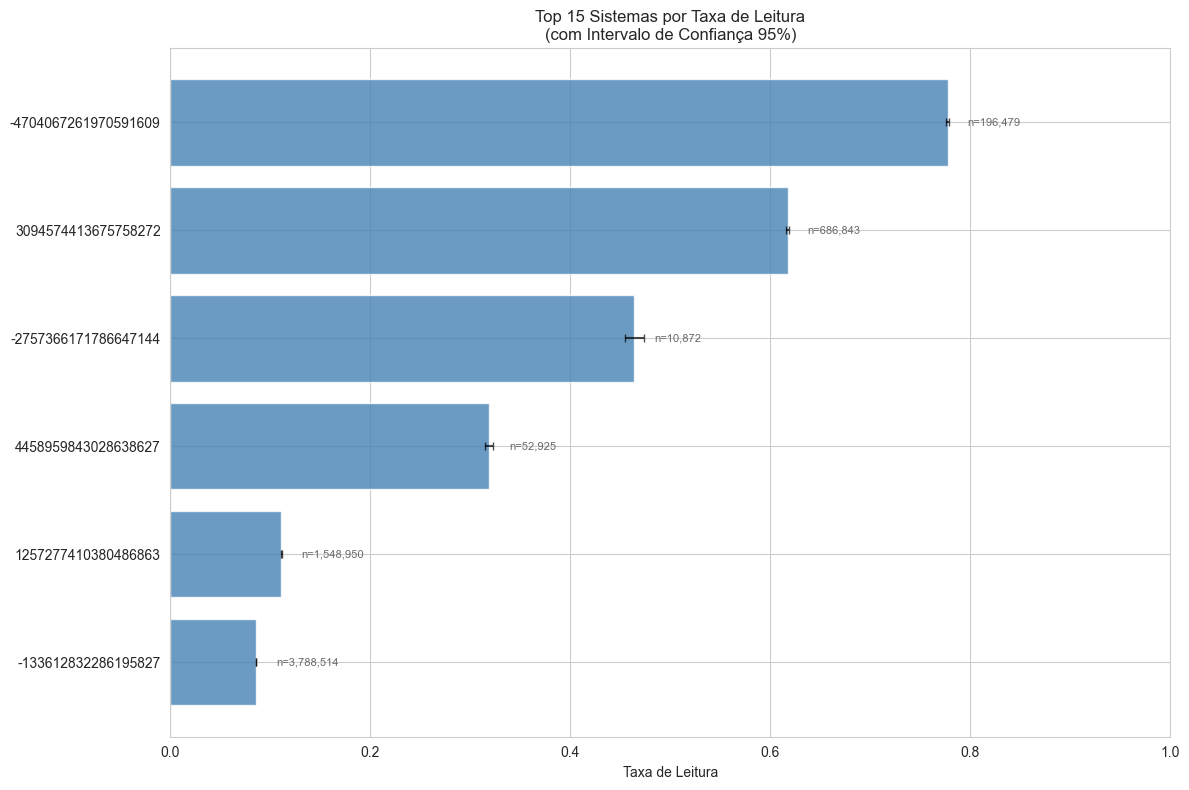

In [ ]:
# métrica bruta
metricas = u.calcular_metricas_sistema(df_disparo_sistema)
print(metricas.head(15))

print()

# WILSON LOWER BOUND
metricas = u.aplicar_wilson(metricas, col_sucessos='read', col_total='total_disparos')

# Renomear para clareza
metricas = metricas.rename(columns={'wilson_lower': 'wilson_lower_read'})

print('Top 15 sistemas por Wilson Lower Bound (leitura):')
print(metricas[['id_sistema', 'total_disparos', 'read', 'taxa_leitura', 
          'taxa_entrega', 'wilson_lower_read']].head(15))


# Selecionar top 15 para visualização
top15 = metricas.head(15).copy()

# Calcular IC superior também para error bars

top15[['ci_low', 'ci_high']] = top15.apply(
    lambda row: pd.Series(proportion_confint(row['read'], row['total_disparos'], 
                                             alpha=0.05, method='wilson')),
    axis=1
)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top15))

# Barras com taxa de leitura
ax.barh(y_pos, top15['taxa_leitura'], color='steelblue', alpha=0.8)

# Error bars (IC de Wilson)
errors = [top15['taxa_leitura'] - top15['ci_low'], 
          top15['ci_high'] - top15['taxa_leitura']]
ax.errorbar(top15['taxa_leitura'], y_pos, xerr=errors, 
            fmt='none', color='black', capsize=3, alpha=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(top15['id_sistema'])
ax.invert_yaxis()
ax.set_xlabel('Taxa de Leitura')
ax.set_title('Top 15 Sistemas por Taxa de Leitura\n(com Intervalo de Confiança 95%)')
ax.set_xlim(0, 1)

# Anotar volume
for i, (idx, row) in enumerate(top15.iterrows()):
    ax.text(row['taxa_leitura'] + 0.02, i, f"n={row['total_disparos']:,}", 
            va='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.show()


---
## 6. Janela de Atualidade — Decaimento Temporal

**Pergunta:** Um telefone atualizado ontem é melhor que um atualizado há 6 meses?

Para responder, calculamos a diferença entre a data do disparo e a
data da última atualização do telefone no sistema de origem.

**Premissa:** Usamos a data de atualização do **próprio sistema** associado
ao disparo (já que cada linha após o join representa um sistema específico).
Se um telefone tem múltiplas atualizações, cada uma é avaliada no contexto
do disparo atribuído àquele sistema.

In [9]:
# ============================================================
# 6.1 CALCULAR DECAIMENTO
# ============================================================
decaimento = u.calcular_decaimento_temporal(df_disparo_sistema)
decaimento


Atenção: 2,590 registros com dias negativos (data de atualização > envio). Serão excluídos.


,faixa_atualizacao,total,read,delivered,failed,taxa_leitura,taxa_entrega
0,<30d,8881,6474,2252,87,0.728972,0.982547
1,30-90d,48110,35699,11067,955,0.742029,0.972064
2,90-180d,485144,344494,109736,4861,0.710086,0.936279
3,180d-1a,356614,153115,110014,7490,0.429358,0.737854
4,1-2a,449515,139849,151655,8899,0.311111,0.648486
5,>2a,249796,108666,75899,7864,0.435019,0.738863


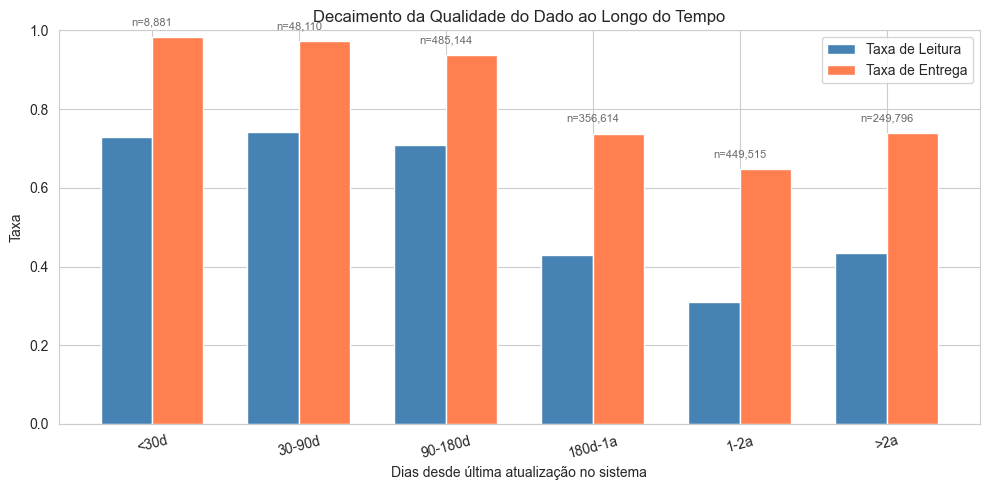

In [10]:
# ============================================================
# 6.2 VISUALIZAÇÃO
# ============================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

x = range(len(decaimento))
width = 0.35

bars1 = ax1.bar([i - width/2 for i in x], decaimento['taxa_leitura'], 
                width, label='Taxa de Leitura', color='steelblue')
bars2 = ax1.bar([i + width/2 for i in x], decaimento['taxa_entrega'], 
                width, label='Taxa de Entrega', color='coral')

ax1.set_ylabel('Taxa')
ax1.set_xlabel('Dias desde última atualização no sistema')
ax1.set_title('Decaimento da Qualidade do Dado ao Longo do Tempo')
ax1.set_xticks(x)
ax1.set_xticklabels(decaimento['faixa_atualizacao'], rotation=15)
ax1.set_ylim(0, 1)
ax1.legend()

# Adicionar volume como anotação
for i, row in decaimento.iterrows():
    ax1.text(i, max(row['taxa_leitura'], row['taxa_entrega']) + 0.03, 
             f"n={row['total']:,}", ha='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 6.3 TESTE ESTATÍSTICO — CHI-SQUARE
# ============================================================
# Testar se a diferença de taxas entre faixas é estatisticamente significativa
contingencia = decaimento[['read', 'failed']].values  # sucesso vs falha
chi2, p_valor, dof, esperado = stats.chi2_contingency(contingencia)

print(f'Chi-square: {chi2:.2f}')
print(f'p-valor: {p_valor:.2e}')
print(f'Graus de liberdade: {dof}')
print()
if p_valor < 0.05:
    print('✅ Diferença ESTATISTICAMENTE SIGNIFICATIVA entre faixas (p < 0.05)')
    print('→ A idade do dado realmente impacta a chance de sucesso.')
else:
    print('❌ Diferença NÃO significativa (p >= 0.05)')
    print('→ Não há evidência estatística de decaimento.')


Chi-square: 11129.76
p-valor: 0.00e+00
Graus de liberdade: 5

✅ Diferença ESTATISTICAMENTE SIGNIFICATIVA entre faixas (p < 0.05)
→ A idade do dado realmente impacta a chance de sucesso.


---
## 7. Tratamento de Viés de Seleção

O enunciado alerta explicitamente: algumas bases já são consideradas
"mais quentes" e aparecem com maior frequência nos logs. Isso cria
um **viés de seleção**: a base X pode parecer melhor não porque é
superior, mas porque os operadores já a pré-selecionaram.

Vamos testar 3 abordagens para mitigar esse viés.

### 7.1 Correlação Volume vs. Taxa de Sucesso

Se sistemas com mais disparos têm taxas mais altas, isso sugere
pré-seleção humana (usam mais a base que "parece" melhor).

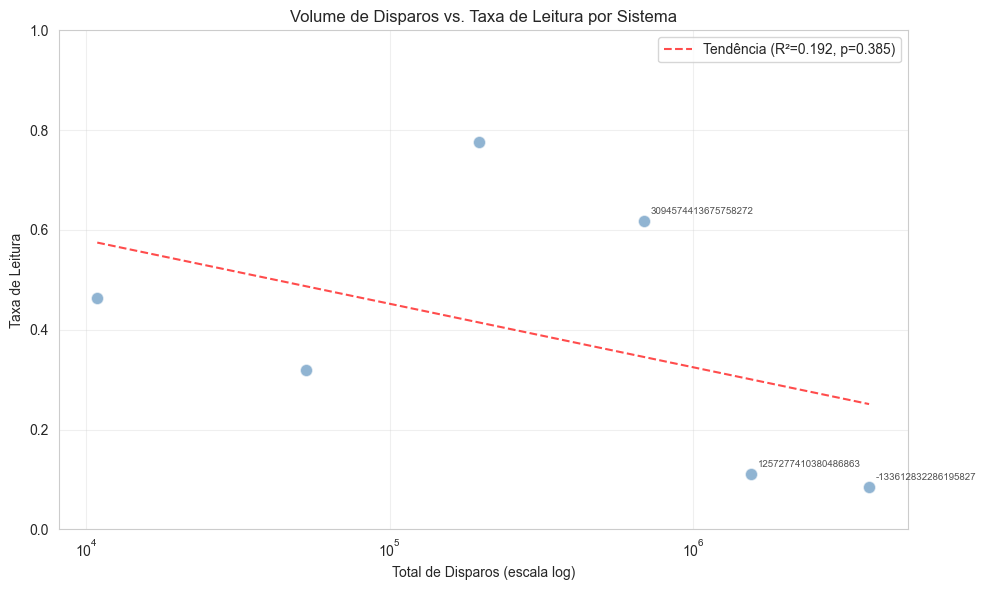

Correlação de Pearson (log volume vs taxa): R=-0.438, p=0.385
✅ Sem correlação significativa. Volume não explica a taxa de sucesso.


In [12]:
# ============================================================
# 7.1 SCATTER: VOLUME VS TAXA DE LEITURA
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(metricas['total_disparos'], metricas['taxa_leitura'], 
           s=80, alpha=0.6, color='steelblue', edgecolors='white')

# Linha de tendência (regressão log)
log_vol = np.log10(metricas['total_disparos'])
slope, intercept, r_value, p_value, std_err = stats.linregress(log_vol, metricas['taxa_leitura'])
x_fit = np.linspace(metricas['total_disparos'].min(), metricas['total_disparos'].max(), 100)
y_fit = slope * np.log10(x_fit) + intercept
ax.plot(x_fit, y_fit, 'r--', alpha=0.7, 
        label=f'Tendência (R²={r_value**2:.3f}, p={p_value:.3f})')

ax.set_xscale('log')
ax.set_xlabel('Total de Disparos (escala log)')
ax.set_ylabel('Taxa de Leitura')
ax.set_title('Volume de Disparos vs. Taxa de Leitura por Sistema')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)

# Anotar sistemas extremos
top_vol = metricas.nlargest(3, 'total_disparos')
for _, row in top_vol.iterrows():
    ax.annotate(row['id_sistema'], 
                (row['total_disparos'], row['taxa_leitura']),
                textcoords="offset points", xytext=(5, 5), 
                fontsize=7, alpha=0.8)

plt.tight_layout()
plt.show()

print(f'Correlação de Pearson (log volume vs taxa): R={r_value:.3f}, p={p_value:.3f}')
if p_value < 0.05:
    print('⚠️  Correlação significativa detectada! Possível viés de pré-seleção.')
else:
    print('✅ Sem correlação significativa. Volume não explica a taxa de sucesso.')


### 7.2 Análise First-Touch

Para cada telefone, isolamos o **primeiro disparo** (ordem cronológica).
Nesse momento, ainda não havia informação histórica sobre aquele telefone,
então a performance reflete apenas a qualidade da fonte de origem —
sem viés de reutilização de números já conhecidos como bons.

In [13]:
# ============================================================
# 7.2 FIRST-TOUCH ANALYSIS
# ============================================================
# Identificar primeiro disparo por telefone
df_disparo['rank_disparo'] = df_disparo.groupby('contato_telefone')['envio_datahora'].rank(method='first')
df_first = df_disparo[df_disparo['rank_disparo'] == 1].copy()

print(f'Total de telefones com first-touch: {df_first["contato_telefone"].nunique():,}')
print(f'Total de first-touch disparos: {len(df_first):,}')

# Join com sistemas (apenas first-touch)
df_first_sistema = u.join_disparo_sistema(df_first, df_aparicoes)

# Recalcular métricas
metricas_first = u.calcular_metricas_sistema(df_first_sistema)
metricas_first = u.aplicar_wilson(metricas_first, col_sucessos='read', col_total='total_disparos')
metricas_first = metricas_first.rename(columns={'wilson_lower': 'wilson_lower_read'})

print('\nTop 10 sistemas (first-touch):')
metricas_first[['id_sistema', 'total_disparos', 'taxa_leitura', 'wilson_lower_read']].head(10)


Total de telefones com first-touch: 293,342


Total de first-touch disparos: 293,342


Disparos com match: 251,599 / 293,342
Total de linhas após join: 1,148,985
Multiplicidade média: 4.57x

Top 10 sistemas (first-touch):


,id_sistema,total_disparos,taxa_leitura,wilson_lower_read
2,-4704067261970591609,135083,0.790521,0.788343
4,3094574413675758272,400392,0.753552,0.752214
5,4458959843028638627,13548,0.700694,0.692926
1,-2757366171786647144,5123,0.677533,0.664604
3,1257277410380486863,193453,0.641045,0.638904
0,-133612832286195827,401386,0.604740,0.603226


In [14]:
# ============================================================
# 7.2 COMPARAR RANKING GERAL VS FIRST-TOUCH
# ============================================================
# Merge para comparar posições
comparacao = metricas[['id_sistema', 'taxa_leitura', 'wilson_lower_read']].merge(
    metricas_first[['id_sistema', 'taxa_leitura', 'wilson_lower_read']],
    on='id_sistema',
    suffixes=('_geral', '_first')
)

# Calcular mudança de ranking
comparacao['rank_geral'] = comparacao['wilson_lower_read_geral'].rank(ascending=False)
comparacao['rank_first'] = comparacao['wilson_lower_read_first'].rank(ascending=False)
comparacao['delta_rank'] = comparacao['rank_geral'] - comparacao['rank_first']

# Sistemas que mais subiram/caíram no first-touch
print('Sistemas que MAIS SUBIRAM no first-touch (possivelmente subestimados no geral):')
display(comparacao.nsmallest(5, 'delta_rank')[['id_sistema', 'rank_geral', 'rank_first', 'delta_rank', 
                                              'taxa_leitura_geral', 'taxa_leitura_first']])

print('\nSistemas que MAIS CAÍRAM no first-touch (possivelmente superestimados no geral):')
display(comparacao.nlargest(5, 'delta_rank')[['id_sistema', 'rank_geral', 'rank_first', 'delta_rank', 
                                             'taxa_leitura_geral', 'taxa_leitura_first']])


Sistemas que MAIS SUBIRAM no first-touch (possivelmente subestimados no geral):


,id_sistema,rank_geral,rank_first,delta_rank,taxa_leitura_geral,taxa_leitura_first
2,-2757366171786647144,3.0,4.0,-1.0,0.463944,0.677533
0,-4704067261970591609,1.0,1.0,0.0,0.777284,0.790521
1,3094574413675758272,2.0,2.0,0.0,0.617256,0.753552
4,1257277410380486863,5.0,5.0,0.0,0.110853,0.641045
5,-133612832286195827,6.0,6.0,0.0,0.085506,0.604740



Sistemas que MAIS CAÍRAM no first-touch (possivelmente superestimados no geral):


,id_sistema,rank_geral,rank_first,delta_rank,taxa_leitura_geral,taxa_leitura_first
3,4458959843028638627,4.0,3.0,1.0,0.318961,0.700694
0,-4704067261970591609,1.0,1.0,0.0,0.777284,0.790521
1,3094574413675758272,2.0,2.0,0.0,0.617256,0.753552
4,1257277410380486863,5.0,5.0,0.0,0.110853,0.641045
5,-133612832286195827,6.0,6.0,0.0,0.085506,0.604740


### 7.3 Comparação Intra-CPF

Para CPFs que têm telefones de **múltiplos sistemas**, comparamos
a performance relativa de cada sistema dentro do mesmo cidadão.

Isso controla viés de perfil do cidadão (ex: CPFs mais ativos podem
ter taxas maiores independente da fonte).

CPFs com telefones de 2+ sistemas: 175,133
Sistemas com maior taxa de vitória intra-CPF:


,id_sistema,vitorias,participacoes,taxa_vitoria
0,-133612832286195827,70781,71811,0.985657
2,-4704067261970591609,81926,125607,0.652241
1,-2757366171786647144,2265,3842,0.589537
3,1257277410380486863,18224,99546,0.183071
4,3094574413675758272,1900,147744,0.012860
5,4458959843028638627,37,12258,0.003018


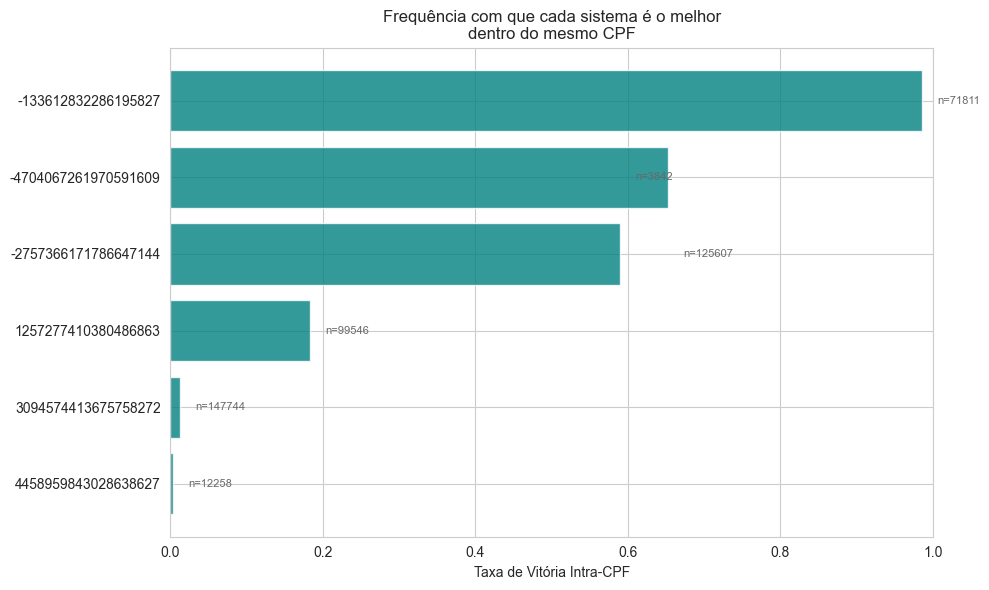

In [15]:
# ============================================================
# 7.3 INTRA-CPF ANALYSIS
# ============================================================
# Passo 1: taxa de leitura por (CPF, sistema)
cpf_sistema = df_disparo_sistema.groupby(['cpf', 'id_sistema']).agg(
    total=('id_disparo', 'count'),
    read=('status_disparo', lambda x: (x == 'read').sum())
).reset_index()

# Filtrar apenas pares com pelo menos 1 disparo
cpf_sistema = cpf_sistema[cpf_sistema['total'] >= 1]
cpf_sistema['taxa_leitura'] = cpf_sistema['read'] / cpf_sistema['total']

# Passo 2: identificar CPFs com múltiplos sistemas
cpf_multi = cpf_sistema.groupby('cpf')['id_sistema'].nunique()
cpf_multi = cpf_multi[cpf_multi >= 2].index

print(f'CPFs com telefones de 2+ sistemas: {len(cpf_multi):,}')

# Passo 3: para cada CPF multi-sistema, rank dos sistemas
cpf_rank = cpf_sistema[cpf_sistema['cpf'].isin(cpf_multi)].copy()
cpf_rank['rank_no_cpf'] = cpf_rank.groupby('cpf')['taxa_leitura'].rank(ascending=False, method='first')

# Passo 4: agregar — com que frequência cada sistema fica em #1?
vitorias = cpf_rank[cpf_rank['rank_no_cpf'] == 1].groupby('id_sistema').size().reset_index(name='vitorias')
participacoes = cpf_rank.groupby('id_sistema').size().reset_index(name='participacoes')

vitorias = vitorias.merge(participacoes, on='id_sistema')
vitorias['taxa_vitoria'] = vitorias['vitorias'] / vitorias['participacoes']
vitorias = vitorias.sort_values('taxa_vitoria', ascending=False)

print('Sistemas com maior taxa de vitória intra-CPF:')
display(vitorias.head(15))

# Visualização
fig, ax = plt.subplots(figsize=(10, 6))
top10_vit = vitorias.head(10)
ax.barh(range(len(top10_vit)), top10_vit['taxa_vitoria'], color='teal', alpha=0.8)
ax.set_yticks(range(len(top10_vit)))
ax.set_yticklabels(top10_vit['id_sistema'])
ax.invert_yaxis()
ax.set_xlabel('Taxa de Vitória Intra-CPF')
ax.set_title('Frequência com que cada sistema é o melhor\ndentro do mesmo CPF')
ax.set_xlim(0, 1)
for i, row in top10_vit.iterrows():
    ax.text(row['taxa_vitoria'] + 0.02, row.name, 
            f"n={row['participacoes']}", va='center', fontsize=8, color='dimgray')
plt.tight_layout()
plt.show()


---
## 8. Sumário da Parte 1 — Entregáveis

Tabela consolidada para transição ao Notebook 02 (Inteligência de Priorização).

In [16]:
# ============================================================
# 8.1 TABELA CONSOLIDADA POR SISTEMA
# ============================================================
# Adicionar informações de viés à tabela principal
metricas_final = metricas[['id_sistema', 'total_disparos', 'read', 'delivered', 'failed',
                           'taxa_leitura', 'taxa_entrega', 'taxa_falha', 'wilson_lower_read']].copy()

# Adicionar rank first-touch (se disponível)
if 'metricas_first' in globals():
    rank_first = metricas_first[['id_sistema']].copy()
    rank_first['rank_first_touch'] = range(1, len(rank_first) + 1)
    metricas_final = metricas_final.merge(rank_first, on='id_sistema', how='left')

# Adicionar taxa de vitória intra-CPF
if 'vitorias' in globals():
    metricas_final = metricas_final.merge(
        vitorias[['id_sistema', 'taxa_vitoria']], 
        on='id_sistema', how='left'
    )

print('=== RANKING CONSOLIDADO DOS SISTEMAS ===')
metricas_final.head(20)


=== RANKING CONSOLIDADO DOS SISTEMAS ===


,id_sistema,total_disparos,read,delivered,failed,taxa_leitura,taxa_entrega,taxa_falha,wilson_lower_read,rank_first_touch,taxa_vitoria
0,-4704067261970591609,196479,152720,42372,505,0.777284,0.992941,0.002570,0.775439,1,0.652241
1,3094574413675758272,686843,423958,170746,18517,0.617256,0.865851,0.026960,0.616106,2,0.012860
2,-2757366171786647144,10872,5044,3568,168,0.463944,0.792127,0.015453,0.454584,4,0.589537
3,4458959843028638627,52925,16881,18328,675,0.318961,0.665262,0.012754,0.315003,3,0.003018
4,1257277410380486863,1548950,171706,618138,9553,0.110853,0.509922,0.006167,0.110360,5,0.183071
5,-133612832286195827,3788514,323942,1491897,98363,0.085506,0.479301,0.025963,0.085225,6,0.985657


In [17]:
# ============================================================
# 8.2 SALVAR RESULTADOS PARA PRÓXIMO NOTEBOOK
# ============================================================
import pickle

# Criar diretório de outputs se não existir
OUTPUT_DIR = u.BASE_DIR / 'data' / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Salvar dataframes e métricas
artefatos = {
    'metricas_sistema': metricas_final,
    'df_disparo_sistema': df_disparo_sistema,
    'decaimento': decaimento,
}

if 'metricas_first' in globals():
    artefatos['metricas_first_touch'] = metricas_first
if 'vitorias' in globals():
    artefatos['vitorias_intra_cpf'] = vitorias

for nome, obj in artefatos.items():
    caminho = OUTPUT_DIR / f'{nome}.pkl'
    with open(caminho, 'wb') as f:
        pickle.dump(obj, f)
    print(f'✅ {nome} salvo em {caminho}')

print('\nArtefatos da Parte 1 salvos. Próximo: Notebook 02 - Inteligência de Priorização.')


✅ metricas_sistema salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_sistema.pkl


✅ df_disparo_sistema salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\df_disparo_sistema.pkl
✅ decaimento salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\decaimento.pkl
✅ metricas_first_touch salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\metricas_first_touch.pkl
✅ vitorias_intra_cpf salvo em C:\Users\deand\Desktop\CODE\CTP_desafio\desafio-cientista-dados-pleno-campanhas\data\processed\vitorias_intra_cpf.pkl

Artefatos da Parte 1 salvos. Próximo: Notebook 02 - Inteligência de Priorização.
